In [1]:
import math
from datetime import timedelta
from operator import attrgetter

import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
import pandas as pd

import parcels
from parcels import StatusCode

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
flowfield_env = xr.open_dataset("../data/ssc.nc")
flowfield_env

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 31, latitude: 85, longitude: 109)
Coordinates:
  * time       (time) datetime64[ns] 248B 2025-08-01 2025-08-02 ... 2025-08-31
  * latitude   (latitude) float32 340B 13.0 13.08 13.17 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 436B -29.0 -28.92 -28.83 ... -20.08 -20.0
    depth      float32 4B ...
Data variables:
    uo         (time, latitude, longitude) float32 1MB ...
    vo         (time, latitude, longitude) float32 1MB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

In [3]:
flowfield_env.uo.data[:,:,0]=0
flowfield_env.uo.data[:,:,-1]=0
flowfield_env.uo.data[:,0,:]=0
flowfield_env.uo.data[:,-1,:]=0
flowfield_env.vo.data[:,:,0]=0
flowfield_env.vo.data[:,:,-1]=0
flowfield_env.vo.data[:,0,:]=0
flowfield_env.vo.data[:,-1,:]=0

In [4]:
ocean_mask = flowfield_env.uo.mean("time").notnull().astype(float)

In [5]:
v_repel = 0.02

mask = ocean_mask.values
nj, ni = mask.shape
u_rep_arr = np.zeros((nj, ni))
v_rep_arr = np.zeros((nj, ni))

for j in range(1, nj - 1):
    for i in range(1, ni - 1):
        if mask[j, i] == 0:
            continue
        if mask[j,   i-1] == 0: u_rep_arr[j, i] += v_repel
        if mask[j,   i+1] == 0: u_rep_arr[j, i] -= v_repel
        if mask[j-1, i  ] == 0: v_rep_arr[j, i] += v_repel
        if mask[j+1, i  ] == 0: v_rep_arr[j, i] -= v_repel

In [6]:
u_repel = xr.DataArray(u_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)
v_repel_field = xr.DataArray(v_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)

In [7]:
flowfield_env["uo"] = flowfield_env.uo + u_repel
flowfield_env["vo"] = flowfield_env.vo + v_repel_field

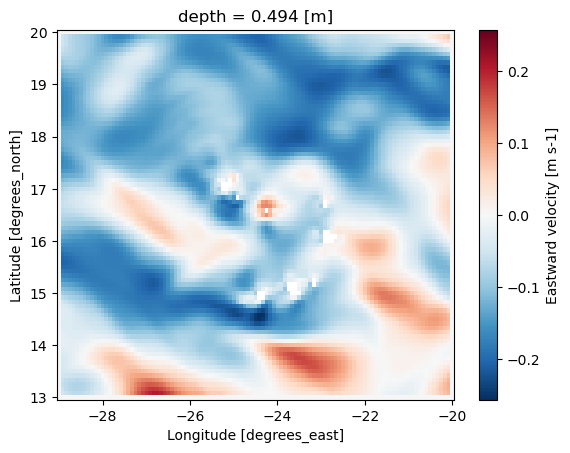

In [8]:
flowfield_env.uo.mean("time").plot()

In [9]:
lon_min = -25.15
lon_max = -24.85
lat_min = 16.70
lat_max = 17.00

delta_m, deg_lat_m = 2000.0, 111320.0

grid_points_lon = 500
grid_points_lat = 500

In [10]:
fieldset = parcels.FieldSet.from_xarray_dataset(flowfield_env, 
                                                variables = {"U": "uo","V": "vo"}, 
                                                dimensions = {"lon": "longitude","lat": "latitude","time": "time"})

In [11]:
print(fieldset)

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
            extrapolate time: False
            time_periodic   : False
            gridindexingtype: 'nemo'
            to_write        : False
        <Field>
            name            : 'V'
            grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)

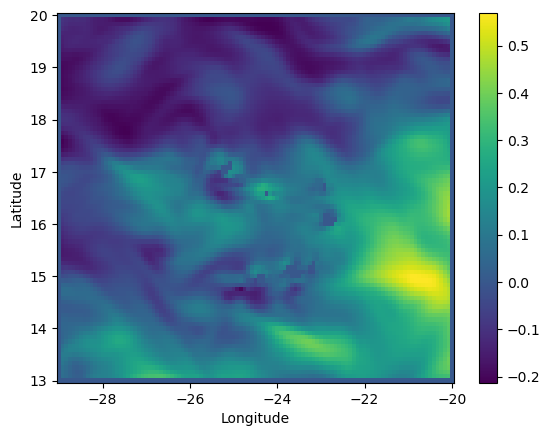

In [12]:
fieldset.computeTimeChunk()

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[10, :, :])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()
plt.show()

In [13]:
lon_grid = np.linspace(lon_min, lon_max, grid_points_lon)
lat_grid = np.linspace(lat_min, lat_max, grid_points_lat)

In [14]:
lons = []
lats = []

for lon in lon_grid:
    for lat in lat_grid:

        lons.append(lon)
        lats.append(lat)

        lons.append(lon + ((delta_m)/deg_lat_m*np.cos(np.radians(lat))))
        lats.append(lat)

        lons.append(lon)
        lats.append(lat + (delta_m/deg_lat_m))

In [15]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lons,
    lat=lats,
    time=np.datetime64("2025-08-12")
)

In [16]:
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], 

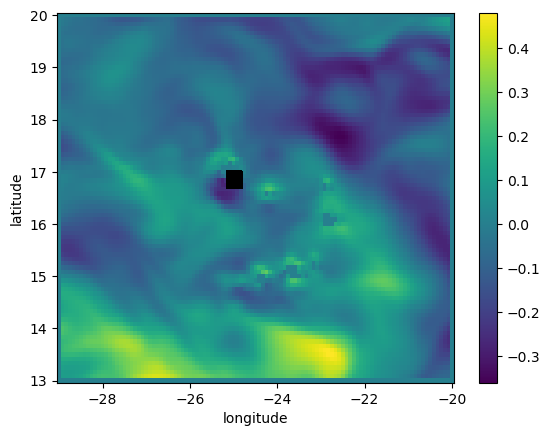

In [17]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[11, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

In [18]:
output_file = pset.ParticleFile(
    name="../data/SV_gridParticles.zarr",
    outputdt=timedelta(hours=1),
)

print(output_file)

ParticleFile(name='../data/SV_gridParticles.zarr', particleset=<parcels.particleset.ParticleSet object at 0x155419a001a0>, outputdt=3600.0, chunks=None, create_new_zarrfile=True)


In [19]:
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

kernels = (
    pset.Kernel(parcels.AdvectionRK4)
    + pset.Kernel(CheckOutOfBounds)
)

pset.execute(
    kernels,
    runtime=timedelta(days=10),
    dt=timedelta(minutes=5),
    output_file=output_file,
)

INFO: Output files are stored in ../data/SV_gridParticles.zarr.
  0%|          | 0/864000.0 [00:00<?, ?it/s]

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 864000.0/864000.0 [22:15<00:00, 647.01it/s]


<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], 

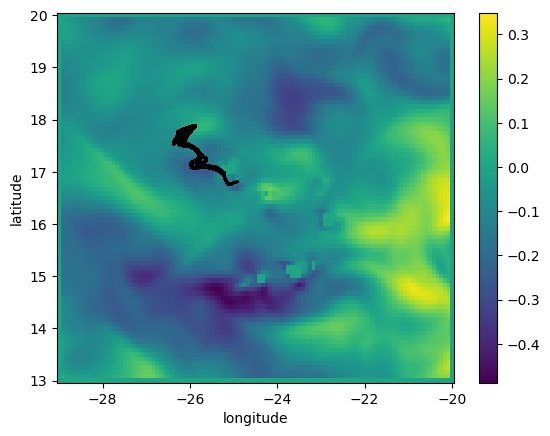

In [20]:
print(pset)

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[21, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize = 1)
plt.show()